# BrushCue Example: Add Frame

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/add_frame.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/add-frame

In [ ]:
!pip install brushcue

[wgpu] using backend 

Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


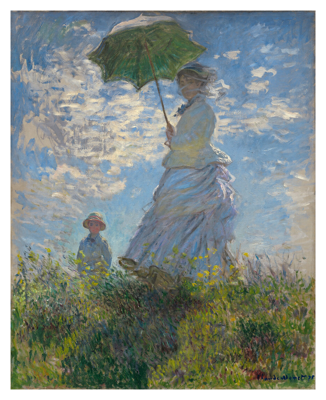

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
input_bounds = input_image.bounds()
frame_center = bc.Point2f.from_components(
    (input_bounds.min_x() + (input_bounds.width() * 0.5)),
    (input_bounds.min_y() + (input_bounds.height() * 0.5)),
)
frame_thickness = 60
thickness = bc.Int.to_float(frame_thickness)
framed_width = input_bounds.width() + (thickness * 2.0)
framed_height = input_bounds.height() + (thickness * 2.0)
frame_color = bc.RGBAColor.from_components(1.0, 1.0, 1.0, 1.0)
frame_style = bc.RenderStyle.fill_only(
    bc.Fill.solid(bc.ProfiledColor.from_rgba_srgb(frame_color))
)
frame_painter = bc.Painter.new().add_rectangle_with_render_style(
    frame_center,
    bc.Vector2f.from_components(framed_width, framed_height),
    0.0,
    frame_style,
    bc.Object.to_list(bc.Transform2.identity()),
)
frame_background = bc.Composition.painter(frame_painter)
graph = input_image.blend_alpha(frame_background, bc.Transform2.identity())

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
